# Quasi-Monte Carlo Option Pricing: Sobol and Halton Sequences

## Problem

Price a European call option under Black-Scholes by Monte Carlo simulation of the terminal
underlying price

```
S_T = S_0 * exp((r - sigma^2/2) T + sigma sqrt(T) Z),   Z ~ N(0,1)
```

and compare the convergence rate of the pricing error against the closed-form Black-Scholes value
for three sampling schemes: standard (pseudo-random) Monte Carlo, and quasi-Monte Carlo with Sobol
and Halton low-discrepancy sequences. A second, higher-dimensional example (a discretely-monitored
Asian call, sampled at d=16 time points) shows the same comparison in a setting closer to practical
use, where the dimension of the sampling problem is large enough that the low-discrepancy advantage
actually matters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm

rng = np.random.default_rng(12345)

# Contract and market parameters
S0 = 100.0
K = 100.0
r = 0.03
sigma = 0.20
T = 1.0


def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


true_price = bs_call_price(S0, K, r, sigma, T)
print(f"Closed-form Black-Scholes call price: {true_price:.6f}")

Closed-form Black-Scholes call price: 9.413403


## Method

**Standard Monte Carlo.** Draw `N` independent standard normals `Z_i`, form `S_T^{(i)}`, and
estimate the price as the discounted sample mean of the payoff `max(S_T - K, 0)`. The root-mean-
square error of this estimator decays as `O(N^{-1/2})`, independent of how the normals are
generated, as long as they are i.i.d.

**Quasi-Monte Carlo.** Replace the pseudo-random uniforms feeding the inverse-CDF transform
(`Z = Phi^{-1}(U)`) with a low-discrepancy sequence — points that fill the unit interval more
evenly than random draws by construction. Two classical constructions are used here:

- **Sobol sequence** (base-2 digital net), generated with `scipy.stats.qmc.Sobol` (scrambled, to
  allow randomized-QMC error estimation via independent scrambles).
- **Halton sequence** (van der Corput sequences in coprime bases), generated with
  `scipy.stats.qmc.Halton`.

For a smooth enough integrand and one effective dimension, QMC error decays close to `O(N^{-1})` —
a full order faster than standard Monte Carlo — instead of `O(N^{-1/2})`. This is measured directly
below: multiple independent randomizations (different pseudo-random seeds for standard MC, different
scrambles for Sobol/Halton) give an RMS error at each sample size `N`, and the empirical decay rate
is read off a log-log plot against reference slopes of `-1/2` and `-1`.

In [2]:
def mc_price_1d(n, seed):
    rng_local = np.random.default_rng(seed)
    z = rng_local.standard_normal(n)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    payoff = np.maximum(ST - K, 0.0)
    return np.exp(-r * T) * payoff.mean()


def qmc_price_1d(n, seed, kind="sobol"):
    if kind == "sobol":
        m = int(np.ceil(np.log2(n)))
        sampler = qmc.Sobol(d=1, scramble=True, seed=seed)
        u = sampler.random_base2(m=m)[:n, 0]
    else:
        sampler = qmc.Halton(d=1, scramble=True, seed=seed)
        u = sampler.random(n)[:, 0]
    u = np.clip(u, 1e-12, 1 - 1e-12)
    z = norm.ppf(u)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    payoff = np.maximum(ST - K, 0.0)
    return np.exp(-r * T) * payoff.mean()


Ns = np.array([2**k for k in range(6, 17)])
n_repeats = 20

results = {"standard": [], "sobol": [], "halton": []}
for n in Ns:
    std_estimates = [mc_price_1d(int(n), seed=1000 + i) for i in range(n_repeats)]
    sob_estimates = [qmc_price_1d(int(n), seed=2000 + i, kind="sobol") for i in range(n_repeats)]
    hal_estimates = [qmc_price_1d(int(n), seed=3000 + i, kind="halton") for i in range(n_repeats)]

    results["standard"].append(np.sqrt(np.mean((np.array(std_estimates) - true_price) ** 2)))
    results["sobol"].append(np.sqrt(np.mean((np.array(sob_estimates) - true_price) ** 2)))
    results["halton"].append(np.sqrt(np.mean((np.array(hal_estimates) - true_price) ** 2)))

for key in results:
    results[key] = np.array(results[key])

# Empirical convergence rate: slope of log(RMSE) vs log(N)
rates = {}
for key in results:
    slope, _ = np.polyfit(np.log(Ns), np.log(results[key]), 1)
    rates[key] = slope
    print(f"{key:10s} empirical RMSE decay rate: N^{slope:.3f}")

standard   empirical RMSE decay rate: N^-0.483
sobol      empirical RMSE decay rate: N^-1.094
halton     empirical RMSE decay rate: N^-0.972


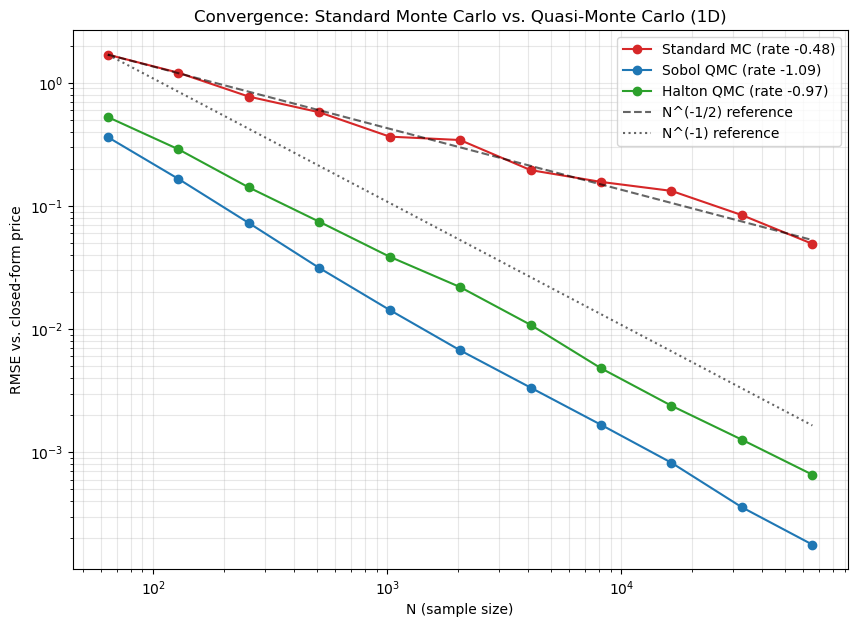

In [3]:
plt.figure(figsize=(10, 7))
plt.loglog(Ns, results["standard"], "o-", label=f"Standard MC (rate {rates['standard']:.2f})", color="tab:red")
plt.loglog(Ns, results["sobol"], "o-", label=f"Sobol QMC (rate {rates['sobol']:.2f})", color="tab:blue")
plt.loglog(Ns, results["halton"], "o-", label=f"Halton QMC (rate {rates['halton']:.2f})", color="tab:green")

ref = results["standard"][0] * (Ns / Ns[0]) ** -0.5
plt.loglog(Ns, ref, "k--", label="N^(-1/2) reference", alpha=0.6)
ref2 = results["standard"][0] * (Ns / Ns[0]) ** -1.0
plt.loglog(Ns, ref2, "k:", label="N^(-1) reference", alpha=0.6)

plt.xlabel("N (sample size)")
plt.ylabel("RMSE vs. closed-form price")
plt.title("Convergence: Standard Monte Carlo vs. Quasi-Monte Carlo (1D)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("qmc_1d_convergence.png", dpi=120, bbox_inches="tight")
plt.show()

## Higher-dimensional example: discretely-monitored Asian call

The 1D case above has only one effective source of randomness, which favors low-discrepancy
sequences in the simplest way. A more realistic test is a path-dependent option that requires
`d` correlated normal draws per path. Here, a discretely-monitored arithmetic Asian call is priced,
averaging the underlying at `d=16` equally-spaced monitoring dates over `[0, T]`, simulated as a
GBM path via independent Gaussian increments (Euler exact-transition simulation, valid since GBM
increments are lognormal in closed form). The Sobol/Halton sequences are generated directly in
`d` dimensions and mapped to the `d` independent normal increments via the inverse Gaussian CDF.

In [4]:
d = 16
dt = T / d
K_asian = 100.0


def simulate_paths_from_z(Z):
    # Z: shape (n_paths, d) standard normals -> GBM path average
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S = np.log(S0) + np.cumsum(increments, axis=1)
    S_path = np.exp(log_S)
    return S_path.mean(axis=1)


def mc_price_asian(n, seed):
    rng_local = np.random.default_rng(seed)
    Z = rng_local.standard_normal((n, d))
    avg = simulate_paths_from_z(Z)
    payoff = np.maximum(avg - K_asian, 0.0)
    return np.exp(-r * T) * payoff.mean()


def qmc_price_asian(n, seed, kind="sobol"):
    if kind == "sobol":
        m = int(np.ceil(np.log2(n)))
        sampler = qmc.Sobol(d=d, scramble=True, seed=seed)
        u = sampler.random_base2(m=m)[:n]
    else:
        sampler = qmc.Halton(d=d, scramble=True, seed=seed)
        u = sampler.random(n)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    Z = norm.ppf(u)
    avg = simulate_paths_from_z(Z)
    payoff = np.maximum(avg - K_asian, 0.0)
    return np.exp(-r * T) * payoff.mean()


# High-accuracy reference price via a very large standard MC run
ref_price_asian = mc_price_asian(4_000_000, seed=999)
print(f"Reference Asian call price (4e6-path standard MC): {ref_price_asian:.5f}")

Ns_asian = np.array([2**k for k in range(8, 16)])
res_asian = {"standard": [], "sobol": [], "halton": []}
for n in Ns_asian:
    std_e = [mc_price_asian(int(n), seed=5000 + i) for i in range(n_repeats)]
    sob_e = [qmc_price_asian(int(n), seed=6000 + i, kind="sobol") for i in range(n_repeats)]
    hal_e = [qmc_price_asian(int(n), seed=7000 + i, kind="halton") for i in range(n_repeats)]

    res_asian["standard"].append(np.sqrt(np.mean((np.array(std_e) - ref_price_asian) ** 2)))
    res_asian["sobol"].append(np.sqrt(np.mean((np.array(sob_e) - ref_price_asian) ** 2)))
    res_asian["halton"].append(np.sqrt(np.mean((np.array(hal_e) - ref_price_asian) ** 2)))

for key in res_asian:
    res_asian[key] = np.array(res_asian[key])

rates_asian = {}
for key in res_asian:
    slope, _ = np.polyfit(np.log(Ns_asian), np.log(res_asian[key]), 1)
    rates_asian[key] = slope
    print(f"[Asian, d={d}] {key:10s} empirical RMSE decay rate: N^{slope:.3f}")

Reference Asian call price (4e6-path standard MC): 5.55045


[Asian, d=16] standard   empirical RMSE decay rate: N^-0.475
[Asian, d=16] sobol      empirical RMSE decay rate: N^-0.492
[Asian, d=16] halton     empirical RMSE decay rate: N^-0.699


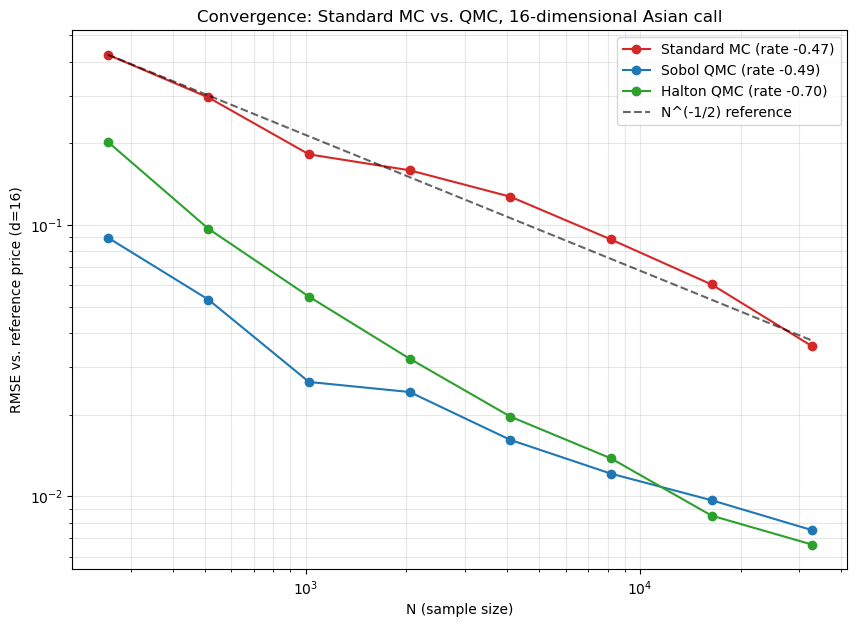

In [5]:
plt.figure(figsize=(10, 7))
plt.loglog(Ns_asian, res_asian["standard"], "o-", label=f"Standard MC (rate {rates_asian['standard']:.2f})", color="tab:red")
plt.loglog(Ns_asian, res_asian["sobol"], "o-", label=f"Sobol QMC (rate {rates_asian['sobol']:.2f})", color="tab:blue")
plt.loglog(Ns_asian, res_asian["halton"], "o-", label=f"Halton QMC (rate {rates_asian['halton']:.2f})", color="tab:green")

ref = res_asian["standard"][0] * (Ns_asian / Ns_asian[0]) ** -0.5
plt.loglog(Ns_asian, ref, "k--", label="N^(-1/2) reference", alpha=0.6)

plt.xlabel("N (sample size)")
plt.ylabel(f"RMSE vs. reference price (d={d})")
plt.title(f"Convergence: Standard MC vs. QMC, {d}-dimensional Asian call")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("qmc_asian_convergence.png", dpi=120, bbox_inches="tight")
plt.show()